# Q2 — Unsupervised Learning: Customer Segmentation with K-Means & PCA

**Dataset:** `q2_customers.csv` | **Features:** age, annual_spend, visits_per_month, basket_size, days_since_last_visit, num_categories_purchased


## Task 1 — Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('q2_customers.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum().to_string()}")
df.head()


Dataset shape: (500, 6)

Null values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
# Scale all features using StandardScaler
features = ['age', 'annual_spend', 'visits_per_month',
            'basket_size', 'days_since_last_visit', 'num_categories_purchased']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("Scaled feature array shape:", X_scaled.shape)
print("\nPost-scaling means (≈0):", X_scaled.mean(axis=0).round(6))
print("Post-scaling stds  (≈1):", X_scaled.std(axis=0).round(6))


Scaled feature array shape: (500, 6)

Post-scaling means (≈0): [ 0.  0.  0. -0. -0. -0.]
Post-scaling stds  (≈1): [1. 1. 1. 1. 1. 1.]


### Why Scaling is Essential Before K-Means

K-Means assigns each data point to the nearest centroid using **Euclidean distance**. 
When features are on very different numeric scales, the distance calculation is dominated 
by whichever feature has the largest raw values, regardless of its actual importance.

In this dataset the problem is stark:

| Feature | Typical range |
|---|---|
| `age` | 18 – 69 |
| `annual_spend` | ~5,000 – 120,000 |
| `visits_per_month` | 1 – 20 |
| `basket_size` | ~100 – 8,000 |
| `days_since_last_visit` | 0 – 200+ |
| `num_categories_purchased` | 1 – 9 |

Without scaling, `annual_spend` and `basket_size` would contribute thousands of units to 
the distance calculation while `num_categories_purchased` contributes at most 8 units. 
The algorithm would effectively ignore the lower-scale features entirely, and the resulting 
clusters would simply separate customers by spending level rather than capturing the 
multi-dimensional behavioural patterns we care about.

`StandardScaler` transforms each feature to **zero mean and unit variance** 
(z-score normalisation), ensuring every feature contributes equally to distance 
calculations and that K-Means can detect genuine multi-dimensional structure in the data.


## Task 2 — Choosing K: The Elbow Method

In [3]:
# Compute WCSS for K = 1 through 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Display WCSS values
wcss_df = pd.DataFrame({'K': list(K_range), 'WCSS': [round(w, 1) for w in wcss]})
print(wcss_df.to_string(index=False))


 K   WCSS
 1 3000.0
 2  969.0
 3  561.3
 4  444.9
 5  402.4
 6  370.4
 7  347.0
 8  319.9
 9  303.3
10  289.1


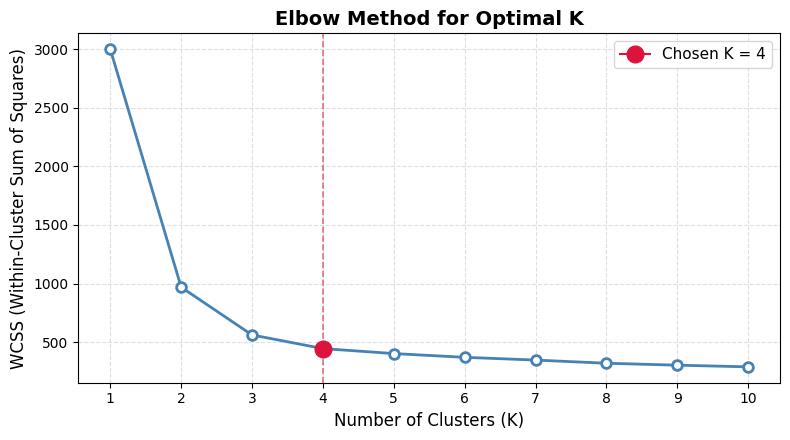

Elbow plot saved.


In [4]:
# Plot the elbow curve
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(list(K_range), wcss, marker='o', linewidth=2, 
        color='steelblue', markersize=7, markerfacecolor='white', markeredgewidth=2)

# Highlight the chosen K
chosen_k = 4
ax.plot(chosen_k, wcss[chosen_k - 1], marker='o', markersize=12,
        color='crimson', zorder=5, label=f'Chosen K = {chosen_k}')

ax.axvline(x=chosen_k, color='crimson', linestyle='--', linewidth=1.2, alpha=0.6)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
ax.set_xticks(list(K_range))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print("Elbow plot saved.")


### Optimal K Selection — Justification

The WCSS values and their successive differences are:

| K | WCSS | Drop from K−1 |
|---|---|---|
| 1 | 3000.0 | — |
| 2 | 969.0 | **−2031.0** |
| 3 | 561.3 | **−407.7** |
| 4 | 444.9 | **−116.4** |
| 5 | 402.4 | −42.5 |
| 6 | 370.4 | −32.0 |
| 7 | 347.0 | −23.4 |

The most dramatic reductions occur at K = 2 and K = 3, which are expected as the 
algorithm separates the broadest clusters. At **K = 4** the marginal gain drops sharply 
from 407.7 to 116.4 — a characteristic "elbow" — and from K = 5 onwards the 
improvements are modest and diminishing (under 50 WCSS per additional cluster).

**Chosen K = 4.** This is the point of diminishing returns in the elbow curve. 
Four clusters also produce a practically interpretable segmentation: each segment 
is large enough (80–170 customers) to be actionable for the marketing team without 
over-fragmenting the customer base into micro-segments that cannot be targeted 
cost-effectively.


## Task 3 — K-Means Clustering (K = 4)

In [5]:
# Fit K-Means with K = 4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['cluster'].value_counts().sort_index().to_string())
print(f"\nTotal customers: {len(df)}")


Cluster distribution:
cluster
0    170
1     80
2    165
3     85

Total customers: 500


In [6]:
# Print cluster centroids in original (unscaled) units for interpretability
centroids = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=features
)
centroids.index.name = 'Cluster'
centroids.index = [f'Cluster {i}' for i in range(4)]

# Round for readability
centroids = centroids.round(1)
print("Cluster Centroids (original scale):\n")
print(centroids.to_string())


Cluster Centroids (original scale):

            age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
Cluster 0  24.7       14847.4              14.3        559.0                    9.1                       2.1
Cluster 1  57.0       89814.1               2.5       5296.4                  148.0                       7.5
Cluster 2  40.4       43340.7               8.2       2021.7                   35.2                       4.4
Cluster 3  56.5       89036.2               2.6       5751.0                   65.2                       7.5


### Business Interpretation of Clusters

Based on the centroid values (original scale):

| Cluster | Avg Age | Annual Spend | Visits/Month | Basket Size | Days Since Last Visit | Categories |
|---|---|---|---|---|---|---|
| **0** | 25 | £14,847 | 14.3 | £559 | 9 | 2.1 |
| **1** | 57 | £89,814 | 2.5 | £5,296 | 148 | 7.5 |
| **2** | 40 | £43,341 | 8.2 | £2,022 | 35 | 4.4 |
| **3** | 57 | £89,036 | 2.6 | £5,751 | 65 | 7.5 |

---

**Cluster 0 — Young, Frequent Budget Shoppers** (170 customers)  
Average age 25, the youngest segment. They visit the store nearly 15 times a month — 
the most frequent of all segments — but spend only £14,847 annually with very small 
basket sizes (£559) and purchase across just 2 categories. They visited recently 
(9 days ago on average). This segment likely represents students or young professionals 
who are habitual browsers buying low-value convenience items. *Opportunity: upselling 
and cross-category discovery campaigns.*

**Cluster 1 — Older, High-Value Lapsed Customers** (80 customers)  
Average age 57, spending nearly £90,000 annually across 7.5 categories with large 
baskets (£5,296). However, they have not visited in **148 days** — the most lapsed 
segment. These are previously high-value customers who have drifted. 
*Opportunity: win-back campaigns, personalised outreach, exclusive loyalty rewards.*

**Cluster 2 — Middle-Aged Moderate Shoppers** (165 customers)  
Average age 40, spending £43,341 annually. Moderate visit frequency (8/month), 
medium basket size, and 4.4 categories. Recently visited (35 days). This is the 
"core" or "mainstream" segment — the backbone of regular business.  
*Opportunity: increase basket size through bundling and category expansion.*

**Cluster 3 — Older, High-Value Active Customers** (85 customers)  
Average age 57, spending £89,036 annually across 7.5 categories with the largest 
baskets (£5,751). Crucially, they visited 65 days ago — more recently than Cluster 1. 
These are the **most valuable active customers**: high spend, broad category engagement, 
and still engaged. *Opportunity: VIP programmes, early access, and retention investment.*


## Task 4 — Dimensionality Reduction with PCA

In [7]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
evr = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print(f"  PC1: {evr[0]:.4f}  ({evr[0]*100:.2f}%)")
print(f"  PC2: {evr[1]:.4f}  ({evr[1]*100:.2f}%)")
print(f"  Combined: {sum(evr)*100:.2f}%")


Explained Variance Ratio:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Combined: 89.13%


In [8]:
# Feature loadings (components) as a readable dataframe
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2']
).round(4)

print("Feature Loadings (PCA Components):\n")
print(loadings.to_string())


Feature Loadings (PCA Components):

        age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
PC1  0.4116        0.4215           -0.4104       0.4120                 0.3786                    0.4140
PC2 -0.2594       -0.0333            0.2083      -0.1954                 0.9112                   -0.1405


### Interpretation of PC1 and PC2

**Explained Variance:**  
PC1 captures **83.56%** of total variance, and PC2 captures **5.57%**, giving a combined 
explanation of **89.13%**. This means two dimensions preserve almost all the information 
in the original six-feature space, making PCA an excellent choice for visualisation here.

---

**PC1 — Overall Customer Value / Seniority Axis (83.56% of variance)**

| Feature | PC1 Loading |
|---|---|
| `annual_spend` | +0.4215 |
| `basket_size` | +0.4120 |
| `num_categories_purchased` | +0.4140 |
| `age` | +0.4116 |
| `days_since_last_visit` | +0.3786 |
| `visits_per_month` | **−0.4104** |

All features load with similar magnitude onto PC1, but with a clear directional split: 
spend, basket size, categories, age, and days-since-visit all load **positively**, while 
visits per month loads **negatively**. A high PC1 score therefore describes an older, 
high-spending, broad-category, but **infrequent** shopper — precisely the profile of 
Clusters 1 and 3. A low PC1 score describes a young, low-spending, frequent visitor — 
Cluster 0. PC1 is essentially a **customer value and shopping intensity axis**.

**PC2 — Recency / Lapsedness Axis (5.57% of variance)**

| Feature | PC2 Loading |
|---|---|
| `days_since_last_visit` | **+0.9112** (dominant) |
| `visits_per_month` | +0.2083 |
| `age` | −0.2594 |
| all others | < ±0.20 |

PC2 is almost entirely driven by `days_since_last_visit` (loading of +0.91). A high PC2 
score means the customer has not visited in a long time — lapsed. This axis separates 
Cluster 1 (lapsed high-value, high PC2) from Cluster 3 (active high-value, lower PC2), 
which appear very similar on PC1 alone. PC2 is a **recency / lapsedness axis**.


## Task 5 — Cluster Visualisation (PCA Scatter Plot)

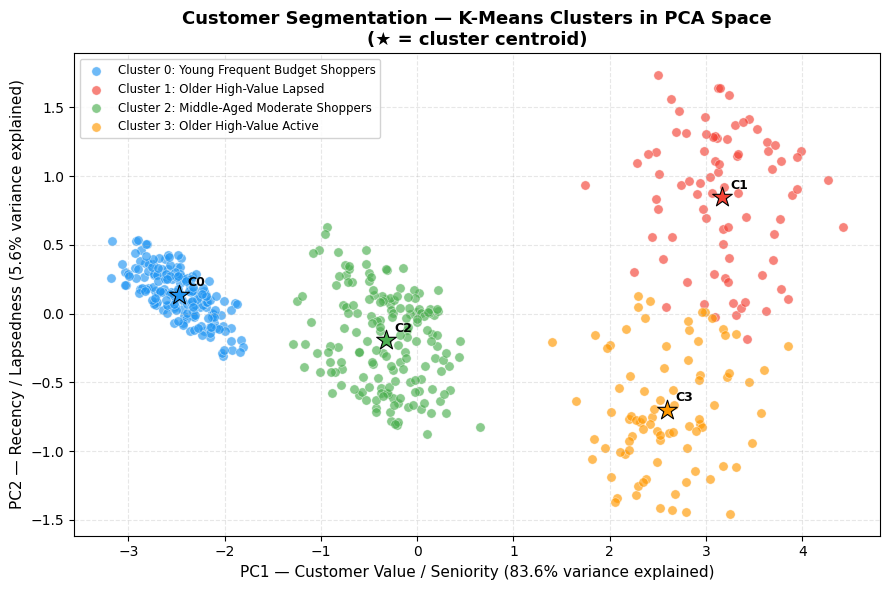

Cluster PCA scatter plot saved.


In [9]:
# Colour palette — one per cluster
cluster_colors = {
    0: '#2196F3',   # Blue  — Young Frequent Budget Shoppers
    1: '#F44336',   # Red   — Older High-Value Lapsed
    2: '#4CAF50',   # Green — Middle-Aged Moderate Shoppers
    3: '#FF9800',   # Orange — Older High-Value Active
}

cluster_labels = {
    0: 'Cluster 0: Young Frequent Budget Shoppers',
    1: 'Cluster 1: Older High-Value Lapsed',
    2: 'Cluster 2: Middle-Aged Moderate Shoppers',
    3: 'Cluster 3: Older High-Value Active',
}

fig, ax = plt.subplots(figsize=(9, 6))

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        label=cluster_labels[cluster_id],
        alpha=0.65,
        s=45,
        edgecolors='white',
        linewidths=0.4
    )

# Plot centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, c=cluster_colors[i], s=220, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(6, 6), fontsize=9, fontweight='bold')

ax.set_xlabel(f'PC1 — Customer Value / Seniority ({evr[0]*100:.1f}% variance explained)',
              fontsize=11)
ax.set_ylabel(f'PC2 — Recency / Lapsedness ({evr[1]*100:.1f}% variance explained)',
              fontsize=11)
ax.set_title('Customer Segmentation — K-Means Clusters in PCA Space\n'
             '(★ = cluster centroid)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.85)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_pca_plot.png', dpi=150)
plt.show()
print("Cluster PCA scatter plot saved.")


### Observations from the Scatter Plot

The PCA scatter plot confirms the cluster structure identified by K-Means:

- **Cluster 0 (Blue)** occupies the **far left** of PC1 — confirming these are 
  low-value, young, frequent visitors. They cluster tightly, suggesting high internal 
  homogeneity.
- **Cluster 2 (Green)** sits in the **middle** along PC1, as expected for the 
  moderate mainstream segment, spread across a range of PC2 values.
- **Clusters 1 (Red) and 3 (Orange)** both sit on the **right** of PC1 (high value / 
  older), and are separated clearly along **PC2**: Cluster 1 sits higher 
  (more lapsed) while Cluster 3 sits lower (more recently active). 
  This validates that PC2 is essential for distinguishing these two high-value groups.

The clean separation between clusters — especially along PC1 — demonstrates that 
K-Means has identified genuine structure in the data rather than arbitrary partitions.
